<a href="https://colab.research.google.com/github/rodrigorissettoterra/SENAI_Concepcao_e_Design_de_ML/blob/main/Previs%C3%A3o_de_nota.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ATIVIDADE 2 - Previsão da nota de avaliação no TripAdvisor

In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

1. Download do dataset via kagglehub

In [2]:
path = kagglehub.dataset_download("andrewmvd/trip-advisor-hotel-reviews")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'trip-advisor-hotel-reviews' dataset.
Path to dataset files: /kaggle/input/trip-advisor-hotel-reviews


2. Localizar o arquivo CSV automaticamente

In [3]:
csv_path = None

for root, dirs, files in os.walk(path):
    for arquivo in files:
        if arquivo.lower().endswith(".csv"):
            csv_path = os.path.join(root, arquivo)
            break
    if csv_path is not None:
        break

if csv_path is None:
    raise FileNotFoundError("Nenhum arquivo CSV foi encontrado no dataset.")

print("CSV encontrado:", csv_path)

CSV encontrado: /kaggle/input/trip-advisor-hotel-reviews/tripadvisor_hotel_reviews.csv


3. Carregar a base

In [4]:
df = pd.read_csv(csv_path)

print("\nPrimeiras linhas:")
print(df.head())

print("\nColunas encontradas:")
print(df.columns.tolist())

print("\nShape original da base:")
print(df.shape)


Primeiras linhas:
                                              Review  Rating
0  nice hotel expensive parking got good deal sta...       4
1  ok nothing special charge diamond member hilto...       2
2  nice rooms not 4* experience hotel monaco seat...       3
3  unique, great stay, wonderful time hotel monac...       5
4  great stay great stay, went seahawk game aweso...       5

Colunas encontradas:
['Review', 'Rating']

Shape original da base:
(20491, 2)


4. Padronizar nomes de colunas

In [5]:
mapa_colunas = {col.lower(): col for col in df.columns}

if "review" not in mapa_colunas:
    raise ValueError("A coluna 'Review' não foi encontrada no dataset.")

if "rating" not in mapa_colunas:
    raise ValueError("A coluna 'Rating' não foi encontrada no dataset.")

col_review = mapa_colunas["review"]
col_rating = mapa_colunas["rating"]

df = df[[col_review, col_rating]].copy()
df.columns = ["Review", "Rating"]

5. Limpeza inicial

In [6]:
df.dropna(subset=["Review", "Rating"], inplace=True)
df["Review"] = df["Review"].astype(str)
df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")
df.dropna(subset=["Rating"], inplace=True)
df["Rating"] = df["Rating"].astype(int)

print("\nShape após limpeza inicial:")
print(df.shape)

print("\nDistribuição das notas:")
print(df["Rating"].value_counts().sort_index())


Shape após limpeza inicial:
(20491, 2)

Distribuição das notas:
Rating
1    1421
2    1793
3    2184
4    6039
5    9054
Name: count, dtype: int64


6. Função de limpeza textual

In [7]:
def limpar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r"<.*?>", " ", texto)          # remove HTML
    texto = re.sub(r"[^a-zA-Z\s]", " ", texto)    # mantém apenas letras
    texto = re.sub(r"\s+", " ", texto).strip()    # remove espaços extras
    return texto

df["Review_Limpa"] = df["Review"].apply(limpar_texto)

# Remove textos vazios após limpeza
df = df[df["Review_Limpa"].str.len() > 0].copy()

print("\nShape após limpeza textual:")
print(df.shape)

print("\nExemplo de review original:")
print(df["Review"].iloc[0])

print("\nExemplo de review limpo:")
print(df["Review_Limpa"].iloc[0])


Shape após limpeza textual:
(20491, 3)

Exemplo de review original:
nice hotel expensive parking got good deal stay hotel anniversary, arrived late evening took advice previous reviews did valet parking, check quick easy, little disappointed non-existent view room room clean nice size, bed comfortable woke stiff neck high pillows, not soundproof like heard music room night morning loud bangs doors opening closing hear people talking hallway, maybe just noisy neighbors, aveda bath products nice, did not goldfish stay nice touch taken advantage staying longer, location great walking distance shopping, overall nice experience having pay 40 parking night,  

Exemplo de review limpo:
nice hotel expensive parking got good deal stay hotel anniversary arrived late evening took advice previous reviews did valet parking check quick easy little disappointed non existent view room room clean nice size bed comfortable woke stiff neck high pillows not soundproof like heard music room night morning 

7. Separar entrada e alvo

In [8]:
X_texto = df["Review_Limpa"]
y = df["Rating"]

8. Bag-of-Words

In [9]:
n_caracteristicas = 5000

vectorizer = CountVectorizer(
    stop_words="english",
    max_features=n_caracteristicas
)

X_bow = vectorizer.fit_transform(X_texto)

print("\nFormato da matriz Bag-of-Words:")
print(X_bow.shape)

print("\nQuantidade real de palavras no vocabulário:")
print(len(vectorizer.vocabulary_))


Formato da matriz Bag-of-Words:
(20491, 5000)

Quantidade real de palavras no vocabulário:
5000


9. Divisão treino/teste

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_bow,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nFormato treino:", X_train.shape)
print("Formato teste:", X_test.shape)


Formato treino: (16392, 5000)
Formato teste: (4099, 5000)


10. Treinamento do modelo

In [11]:
modelo = LogisticRegression(
    max_iter=2000,
    random_state=42
)

modelo.fit(X_train, y_train)

LogisticRegression(max_iter=2000, random_state=42)

11. Predição

In [12]:
y_pred = modelo.predict(X_test)

12. Avaliação

In [13]:
acc = accuracy_score(y_test, y_pred)

print("\nAcurácia do modelo:", round(acc, 4))
print("\nRelatório de classificação:\n")
print(classification_report(y_test, y_pred, zero_division=0))


Acurácia do modelo: 0.5587

Relatório de classificação:

              precision    recall  f1-score   support

           1       0.65      0.62      0.63       284
           2       0.40      0.40      0.40       359
           3       0.30      0.28      0.29       437
           4       0.45      0.46      0.45      1208
           5       0.70      0.72      0.71      1811

    accuracy                           0.56      4099
   macro avg       0.50      0.49      0.50      4099
weighted avg       0.56      0.56      0.56      4099



13. Matriz de confusão

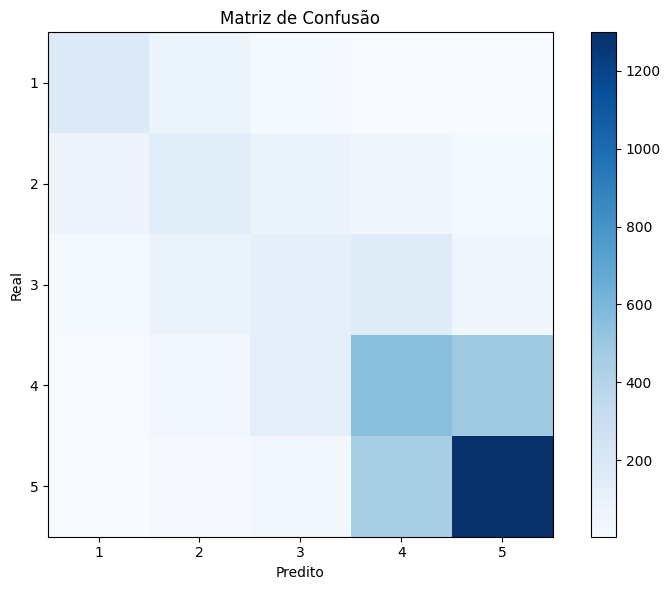

In [14]:
labels_ordenados = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels_ordenados)

plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap="Blues")
plt.title("Matriz de Confusão")
plt.colorbar()
plt.xticks(range(len(labels_ordenados)), labels_ordenados)
plt.yticks(range(len(labels_ordenados)), labels_ordenados)
plt.xlabel("Predito")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

14. Mostrar parte do vocabulário

In [15]:
vocabulario = vectorizer.get_feature_names_out()

print("\nPrimeiras 50 palavras do vocabulário:")
print(vocabulario[:50])


Primeiras 50 palavras do vocabulário:
['aaa' 'abc' 'ability' 'able' 'abroad' 'absolute' 'absolutely' 'absolutly'
 'abundance' 'abundant' 'ac' 'accademia' 'accept' 'acceptable' 'accepted'
 'access' 'accessed' 'accessible' 'accident' 'accommodate' 'accommodated'
 'accommodating' 'accommodation' 'accommodations' 'accomodate'
 'accomodated' 'accomodating' 'accomodation' 'accomodations' 'accompanied'
 'according' 'accordingly' 'account' 'accross' 'accurate' 'accustomed'
 'acknowledge' 'acknowledged' 'act' 'acted' 'action' 'active' 'activites'
 'activities' 'activity' 'actual' 'actually' 'adagio' 'add' 'added']


15. Exemplo de previsão manual

In [16]:
nova_avaliacao = [
    "The hotel was amazing, very clean, the staff was friendly and the breakfast was excellent"
]

nova_avaliacao_limpa = [limpar_texto(texto) for texto in nova_avaliacao]
nova_avaliacao_bow = vectorizer.transform(nova_avaliacao_limpa)
nota_prevista = modelo.predict(nova_avaliacao_bow)[0]

print("\nNova avaliação:")
print(nova_avaliacao[0])
print("Nota prevista:", nota_prevista)


Nova avaliação:
The hotel was amazing, very clean, the staff was friendly and the breakfast was excellent
Nota prevista: 5


16. Exibir a matriz final do pós-processamento

In [17]:
print("\nMatriz final Bag-of-Words:")
print(X_bow)

print("\nShape final da matriz:")
print(X_bow.shape)


Matriz final Bag-of-Words:
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 1473477 stored elements and shape (20491, 5000)>
  Coords	Values
  (0, 2911)	5
  (0, 2153)	2
  (0, 1584)	1
  (0, 3121)	3
  (0, 1935)	1
  (0, 1930)	1
  (0, 1158)	1
  (0, 4229)	2
  (0, 155)	1
  (0, 231)	1
  (0, 2443)	1
  (0, 1533)	1
  (0, 4528)	1
  (0, 74)	1
  (0, 3367)	1
  (0, 3686)	1
  (0, 1246)	2
  (0, 4729)	1
  (0, 758)	1
  (0, 3459)	1
  (0, 1426)	1
  (0, 2528)	1
  (0, 1282)	1
  (0, 2930)	1
  (0, 1573)	1
  :	:
  (20490, 4683)	1
  (20490, 4970)	1
  (20490, 4983)	2
  (20490, 446)	2
  (20490, 1770)	2
  (20490, 4240)	1
  (20490, 4243)	2
  (20490, 562)	1
  (20490, 2016)	1
  (20490, 409)	1
  (20490, 3500)	1
  (20490, 1922)	1
  (20490, 2255)	1
  (20490, 1645)	1
  (20490, 4493)	1
  (20490, 2981)	1
  (20490, 1402)	1
  (20490, 1600)	1
  (20490, 1989)	1
  (20490, 1911)	1
  (20490, 1147)	1
  (20490, 2250)	1
  (20490, 3138)	1
  (20490, 2433)	1
  (20490, 1760)	1

Shape final da matriz:
(20491, 5000)


17. Exibir as 10 palavras mais importantes por classe

In [18]:
classes_modelo = modelo.classes_
coeficientes = modelo.coef_
nomes_features = vectorizer.get_feature_names_out()

print("\nPalavras mais relevantes por nota:\n")

for i, classe in enumerate(classes_modelo):
    top_indices = np.argsort(coeficientes[i])[-10:]
    top_palavras = nomes_features[top_indices]
    print(f"Nota {classe}: {list(top_palavras)}")


Palavras mais relevantes por nota:

Nota 1: ['uncomfortable', 'rude', 'disappointing', 'unhelpful', 'horrible', 'shocked', 'avoid', 'awful', 'terrible', 'worst']
Nota 2: ['build', 'stale', 'salad', 'taps', 'okay', 'hanging', 'cleaner', 'disappointment', 'earplugs', 'positives']
Nota 3: ['currently', 'motor', 'eur', 'flower', 'busses', 'trek', 'okay', 'average', 'excuse', 'hoped']
Nota 4: ['sensitive', 'defintely', 'movie', 'trap', 'toothpaste', 'hook', 'liquor', 'folded', 'record', 'unsure']
Nota 5: ['extremly', 'error', 'beautifull', 'opens', 'shaving', 'perfect', 'fantastic', 'loved', 'shoe', 'cooling']


18. Salvar uma amostra da base processada

In [19]:
df_saida = df[["Review", "Review_Limpa", "Rating"]].copy()
df_saida.to_csv("tripadvisor_reviews_processado.csv", index=False)

print("\nArquivo salvo: tripadvisor_reviews_processado.csv")


Arquivo salvo: tripadvisor_reviews_processado.csv
